# Differential decay rate

`transporttk.localprobe.LocalProbe` models a single STM-like tip weakly coupled to one site of a
bulk sample. `get_kappa` extracts a decay-constant/transparency-scaling diagnostic
$\kappa=d\log G/d\log T$: how steeply the conductance scales with the probe-sample coupling
$T$. Away from the gap, single-particle tunneling conductance scales linearly with the coupling
($G\propto T$, so $\kappa=1$); deep inside the gap, where transport can only proceed via Andreev
reflection (a two-electron, Cooper-pair-transferring process), conductance instead scales
quadratically ($G\propto T^2$, so $\kappa=2$). This is the signature used experimentally to
distinguish Andreev-dominated sub-gap transport from ordinary single-particle tunneling.

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import heterostructures

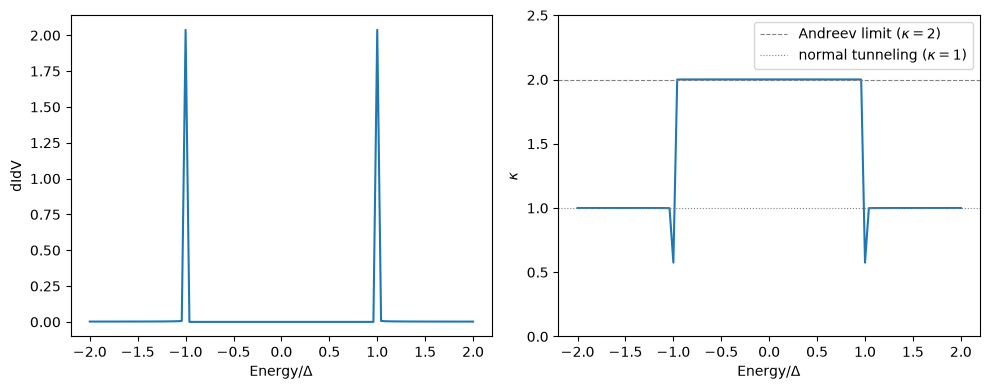

In [2]:
from pyqula.heterostructures import LocalProbe

g = geometry.chain()
h = g.get_hamiltonian()
h.shift_fermi(1.)
D = 0.1 # superconducting gap
h.add_swave(D)
lp = LocalProbe(h,delta=1e-8)
lp.T = 2e-2 # reference (small, tunneling) transparency
es = np.linspace(-2*D,2*D,101)
ts = [lp.didv(energy=e) for e in es]
ks = [lp.get_kappa(energy=e) for e in es] # decay rate kappa = d log G / d log T

fig,axs = plt.subplots(1,2,figsize=(10,4))
axs[0].plot(es/D,ts) ; axs[0].set_xlabel(r"Energy/$\Delta$") ; axs[0].set_ylabel("dIdV")
axs[1].plot(es/D,ks) ; axs[1].set_xlabel(r"Energy/$\Delta$") ; axs[1].set_ylabel(r"$\kappa$")
axs[1].axhline(2.0,c="grey",ls="--",lw=0.8,label=r"Andreev limit ($\kappa=2$)")
axs[1].axhline(1.0,c="grey",ls=":",lw=0.8,label=r"normal tunneling ($\kappa=1$)")
axs[1].set_ylim([0,2.5]) ; axs[1].legend()
plt.tight_layout()
plt.show()

Repeating the extraction at several reference couplings $T$ gives $\kappa$ as a map over the energy and the coupling.
At the smallest coupling the broadening `delta` of the probe leaves a small density of states inside the gap, whose single-particle tunneling scales linearly with $T$ and takes over from Andreev reflection, and close to contact $\kappa$ departs from both limits.

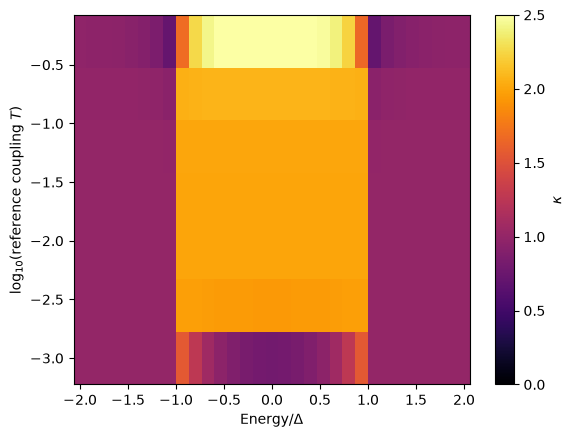

In [3]:
Tps = np.logspace(-3,-0.3,7) # reference couplings, from deep tunneling towards contact
es_map = np.linspace(-2*D,2*D,31)
kmap = [lp.get_kappa(energies=es_map,T=T) for T in Tps] # kappa at each coupling

plt.pcolormesh(es_map/D,np.log10(Tps),np.array(kmap),shading="auto",cmap="inferno",vmin=0,vmax=2.5)
plt.colorbar(label=r"$\kappa$")
plt.xlabel(r"Energy/$\Delta$") ; plt.ylabel("log$_{10}$(reference coupling $T$)")
plt.show()